# 23 - テキスト検索の評価（SigLIP）

## 概要
SigLIP (google/siglip-base-patch16-224) を使ったテキストによる画像検索の性能を評価する。
実験22（CLIP-L）との比較を行い、特に日本語クエリでの性能差を確認する。

## 評価の観点
1. **テキストクエリで適切な画像が検索されるか？** → Precision@K, MRR
2. **英語 vs 日本語クエリ** → 言語による性能差
3. **CLIP-L との比較** → モデル間の性能差

## SigLIPの特徴
- Googleが開発したCLIPの改良版
- Sigmoid損失関数を使用（CLIPはSoftmax）
- 多言語対応が改善されている可能性

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from image_vector_poc import SigLIPEmbedder

## 1. データの読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
MODEL_NAME = "google/siglip-base-patch16-224"

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_query = """
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
"""
catalog_df = conn.execute(catalog_query).fetchdf()

print(f"Total images: {len(catalog_df)}")
print(f"\nCategories:")
category_counts = catalog_df['category'].value_counts().to_dict()
for cat, count in category_counts.items():
    print(f"  {cat}: {count}")

Total images: 378

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


In [3]:
# SigLIPの埋め込みを読み込み（カタログと結合して順序を一致させる）
embeddings_query = """
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
"""
embeddings_df = conn.execute(embeddings_query, [MODEL_NAME]).fetchdf()
conn.close()

print(f"Loaded {len(embeddings_df)} embeddings")

if len(embeddings_df) == 0:
    raise ValueError(f"No embeddings found for {MODEL_NAME}. Please run notebook 02 first.")

# 埋め込みをNumPy配列に変換
image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
print(f"Embeddings shape: {image_embeddings.shape}")

# ノルムの確認
norms = np.linalg.norm(image_embeddings, axis=1)
print(f"Embedding norms - Mean: {norms.mean():.4f}, Min: {norms.min():.4f}, Max: {norms.max():.4f}")

# 正規化（コサイン類似度用）
norms_for_norm = np.clip(norms.reshape(-1, 1), 1e-8, None)
image_embeddings_normalized = image_embeddings / norms_for_norm

# カテゴリリストを取得
categories = catalog_df['category'].tolist()
category_names = list(category_counts.keys())

Loaded 378 embeddings
Embeddings shape: (378, 768)
Embedding norms - Mean: 1.0000, Min: 1.0000, Max: 1.0000


## 2. SigLIPモデルの読み込み（テキスト埋め込み用）

In [4]:
# SigLIPモデルを読み込み（テキスト埋め込み用）
embedder = SigLIPEmbedder(model_name=MODEL_NAME, device="cuda")
print(f"Model loaded: {embedder.model_name}")
print(f"Embedding dimension: {embedder.embedding_dim}")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Model loaded: google/siglip-base-patch16-224
Embedding dimension: 768


## 3. テストクエリの定義

実験22と同じテストクエリを使用する。

In [5]:
# テストクエリの定義（実験22と同じ）
test_queries = [
    # カテゴリ固有のクエリ（英語）
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "village park with greenery", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "en"},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "city lights at night", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "en"},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "conference hall with audience", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "speaker giving a talk", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "en"},
    {"query": "portrait photo of a person", "expected_categories": ["terada"], "type": "specific", "lang": "en"},
    
    # 一般的なクエリ（英語）
    {"query": "outdoor nature scene", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "en"},
    {"query": "urban night photography", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "en"},
    {"query": "tech conference event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    {"query": "people at an event", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "general", "lang": "en"},
    
    # 日本語クエリ
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"], "type": "specific", "lang": "ja"},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"], "type": "specific", "lang": "ja"},
    {"query": "カンファレンスの講演", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"], "type": "specific", "lang": "ja"},
    {"query": "人物の写真", "expected_categories": ["terada"], "type": "specific", "lang": "ja"},
    {"query": "緑の木々", "expected_categories": ["KashiwaVillagePark2026"], "type": "general", "lang": "ja"},
    {"query": "夜の街", "expected_categories": ["TokyoNight202505"], "type": "general", "lang": "ja"},
]

print(f"Total test queries: {len(test_queries)}")
print(f"  English: {sum(1 for q in test_queries if q['lang'] == 'en')}")
print(f"  Japanese: {sum(1 for q in test_queries if q['lang'] == 'ja')}")

Total test queries: 18
  English: 12
  Japanese: 6


## 4. テキスト検索の実行

In [6]:
def search_by_text(query: str, embedder, image_embeddings: np.ndarray, top_k: int = 20):
    """テキストクエリで画像を検索する。"""
    # テキストを埋め込みに変換
    text_embedding = embedder.embed_text(query)
    
    # 正規化
    text_embedding = text_embedding / np.linalg.norm(text_embedding)
    
    # コサイン類似度を計算
    similarities = np.dot(image_embeddings, text_embedding)
    
    # 上位K件のインデックスを取得
    top_indices = np.argsort(similarities)[::-1][:top_k]
    top_scores = similarities[top_indices]
    
    return top_indices, top_scores

# テスト
test_query = "a park with trees"
indices, scores = search_by_text(test_query, embedder, image_embeddings_normalized, top_k=5)
print(f"Query: {test_query}")
print(f"Top 5 results:")
for i, (idx, score) in enumerate(zip(indices, scores)):
    print(f"  {i+1}. {categories[idx]} (score: {score:.4f})")

Query: a park with trees
Top 5 results:
  1. EuroPython2025 (score: 0.1041)
  2. PyConJP2025-PreCampHiroshima (score: 0.1033)
  3. PyConJP2025 (score: 0.0929)
  4. PyConJP2025-PreCampHiroshima (score: 0.0929)
  5. PyConJP2025-PreCampHiroshima (score: 0.0903)


## 5. 評価メトリクスの計算

In [7]:
def evaluate_query(query_info: dict, embedder, image_embeddings: np.ndarray, 
                   categories: list, k_values: list = [1, 5, 10, 20]):
    """単一のクエリを評価する。"""
    query = query_info["query"]
    expected_cats = query_info["expected_categories"]
    
    # 検索実行
    max_k = max(k_values)
    indices, scores = search_by_text(query, embedder, image_embeddings, top_k=max_k)
    
    # 結果のカテゴリを取得
    result_categories = [categories[idx] for idx in indices]
    
    # 正解判定（期待されるカテゴリに含まれるか）
    is_relevant = [cat in expected_cats for cat in result_categories]
    
    # Precision@K
    precision_at_k = {}
    for k in k_values:
        relevant_in_k = sum(is_relevant[:k])
        precision_at_k[f"P@{k}"] = relevant_in_k / k
    
    # MRR (Mean Reciprocal Rank) - 最初の正解の順位
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    
    # Hit Rate@K
    hit_rate_at_k = {}
    for k in k_values:
        hit_rate_at_k[f"HR@{k}"] = 1.0 if any(is_relevant[:k]) else 0.0
    
    return {
        "query": query,
        "expected_categories": expected_cats,
        "type": query_info["type"],
        "lang": query_info["lang"],
        "top_results": result_categories[:10],
        "top_scores": scores[:10].tolist(),
        **precision_at_k,
        "MRR": mrr,
        **hit_rate_at_k,
    }

In [8]:
# 全クエリの評価
print("Evaluating all queries...")
results = []

for query_info in test_queries:
    result = evaluate_query(query_info, embedder, image_embeddings_normalized, categories)
    results.append(result)
    print(f"  {query_info['query'][:40]:40s} | P@1={result['P@1']:.2f} | P@10={result['P@10']:.2f} | MRR={result['MRR']:.2f}")

print("\nEvaluation complete!")

Evaluating all queries...
  a park with trees and nature             | P@1=0.00 | P@10=0.30 | MRR=0.33
  village park with greenery               | P@1=0.00 | P@10=0.00 | MRR=0.08
  night cityscape Tokyo                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  city lights at night                     | P@1=1.00 | P@10=1.00 | MRR=1.00
  Python conference presentation           | P@1=1.00 | P@10=1.00 | MRR=1.00
  conference hall with audience            | P@1=1.00 | P@10=1.00 | MRR=1.00
  speaker giving a talk                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  portrait photo of a person               | P@1=1.00 | P@10=0.80 | MRR=1.00
  outdoor nature scene                     | P@1=0.00 | P@10=0.70 | MRR=0.50
  urban night photography                  | P@1=1.00 | P@10=1.00 | MRR=1.00
  tech conference event                    | P@1=1.00 | P@10=1.00 | MRR=1.00
  people at an event                       | P@1=1.00 | P@10=1.00 | MRR=1.00
  公園の自然風景                                  | P@1=1

  カンファレンスの講演                               | P@1=1.00 | P@10=0.90 | MRR=1.00


  人物の写真                                    | P@1=0.00 | P@10=0.30 | MRR=0.50
  緑の木々                                     | P@1=0.00 | P@10=0.30 | MRR=0.33
  夜の街                                      | P@1=1.00 | P@10=0.90 | MRR=1.00

Evaluation complete!


## 6. 結果サマリー

In [9]:
# 結果をDataFrameに変換
results_df = pd.DataFrame(results)

# 全体の平均
print("=" * 60)
print("Overall Results (SigLIP)")
print("=" * 60)

metric_cols = ["P@1", "P@5", "P@10", "P@20", "MRR", "HR@1", "HR@5", "HR@10"]
overall_means = results_df[metric_cols].mean()

for metric, value in overall_means.items():
    print(f"  {metric}: {value:.4f}")

Overall Results (SigLIP)
  P@1: 0.7222
  P@5: 0.7556
  P@10: 0.7444
  P@20: 0.7111
  MRR: 0.8194
  HR@1: 0.7222
  HR@5: 0.9444
  HR@10: 0.9444


In [10]:
# 言語別の結果
print("\n" + "=" * 60)
print("Results by Language")
print("=" * 60)

lang_results = results_df.groupby("lang")[metric_cols].mean()
display(lang_results.round(4))


Results by Language


,P@1,P@5,P@10,P@20,MRR,HR@1,HR@5,HR@10
lang,,,,,,,,
en,0.7500,0.8167,0.8167,0.7917,0.8264,0.7500,0.9167,0.9167
ja,0.6667,0.6333,0.6000,0.5500,0.8056,0.6667,1.0000,1.0000


In [11]:
# クエリタイプ別の結果
print("\n" + "=" * 60)
print("Results by Query Type")
print("=" * 60)

type_results = results_df.groupby("type")[metric_cols].mean()
display(type_results.round(4))


Results by Query Type


,P@1,P@5,P@10,P@20,MRR,HR@1,HR@5,HR@10
type,,,,,,,,
general,0.6667,0.8000,0.8167,0.7917,0.8056,0.6667,1.0000,1.0000
specific,0.7500,0.7333,0.7083,0.6708,0.8264,0.7500,0.9167,0.9167


## 7. CLIP-L との比較

In [12]:
# 実験22のCLIP-L結果（2026-02-03修正後の最新値）
clip_results = {
    "overall": {"P@1": 0.7778, "P@5": 0.8222, "P@10": 0.8000, "MRR": 0.8611, "HR@5": 0.9444},
    "en": {"P@1": 0.75, "P@10": 0.8583, "MRR": 0.875},
    "ja": {"P@1": 0.8333, "P@10": 0.6833, "MRR": 0.8333},
}

# SigLIPの結果
siglip_results = {
    "overall": overall_means.to_dict(),
    "en": lang_results.loc["en"].to_dict() if "en" in lang_results.index else {},
    "ja": lang_results.loc["ja"].to_dict() if "ja" in lang_results.index else {},
}

print("=" * 60)
print("Model Comparison: CLIP-L vs SigLIP")
print("=" * 60)

print("\n### Overall Performance")
print(f"{'Metric':<10} {'CLIP-L':>10} {'SigLIP':>10} {'Diff':>10}")
print("-" * 42)
for metric in ["P@1", "P@10", "MRR", "HR@5"]:
    clip_val = clip_results["overall"].get(metric, 0)
    siglip_val = siglip_results["overall"].get(metric, 0)
    diff = siglip_val - clip_val
    sign = "+" if diff > 0 else ""
    print(f"{metric:<10} {clip_val:>10.4f} {siglip_val:>10.4f} {sign}{diff:>9.4f}")

Model Comparison: CLIP-L vs SigLIP

### Overall Performance
Metric         CLIP-L     SigLIP       Diff
------------------------------------------
P@1            0.7778     0.7222   -0.0556
P@10           0.8000     0.7444   -0.0556
MRR            0.8611     0.8194   -0.0417
HR@5           0.9444     0.9444 +   0.0000


In [13]:
# 言語別の比較
print("\n### Performance by Language")

for lang, lang_name in [("en", "English"), ("ja", "Japanese")]:
    print(f"\n{lang_name}:")
    print(f"{'Metric':<10} {'CLIP-L':>10} {'SigLIP':>10} {'Diff':>10}")
    print("-" * 42)
    for metric in ["P@1", "P@10", "MRR"]:
        clip_val = clip_results[lang].get(metric, 0)
        siglip_val = siglip_results[lang].get(metric, 0)
        diff = siglip_val - clip_val
        sign = "+" if diff > 0 else ""
        print(f"{metric:<10} {clip_val:>10.4f} {siglip_val:>10.4f} {sign}{diff:>9.4f}")


### Performance by Language

English:
Metric         CLIP-L     SigLIP       Diff
------------------------------------------
P@1            0.7500     0.7500    0.0000
P@10           0.8583     0.8167   -0.0416
MRR            0.8750     0.8264   -0.0486

Japanese:
Metric         CLIP-L     SigLIP       Diff
------------------------------------------
P@1            0.8333     0.6667   -0.1666
P@10           0.6833     0.6000   -0.0833
MRR            0.8333     0.8056   -0.0277


## 8. 可視化

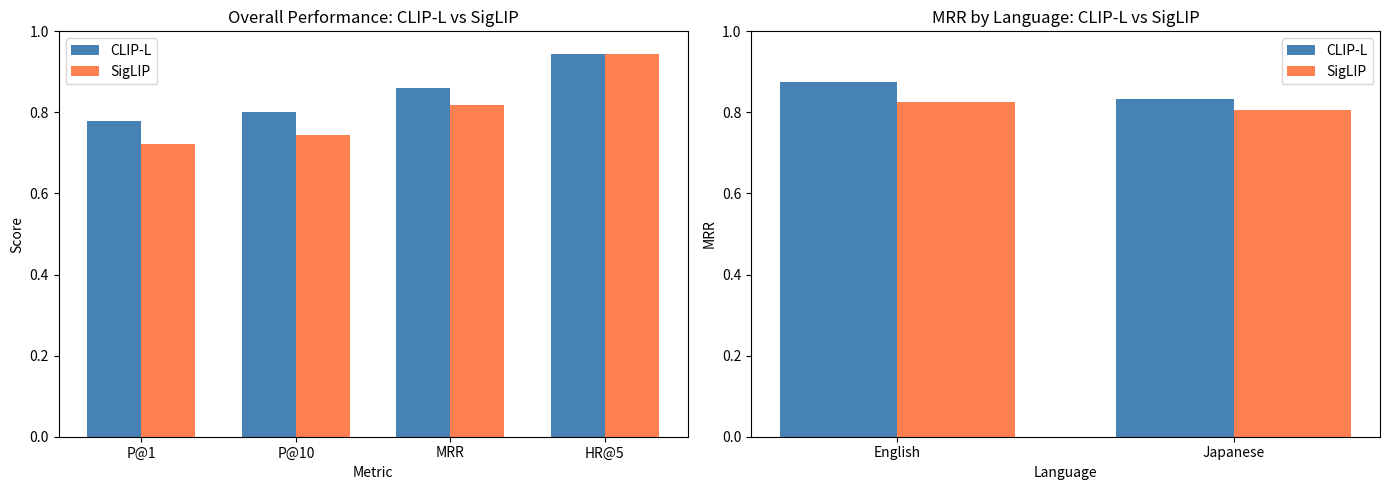

Saved: data/text_search_model_comparison.png


In [14]:
# モデル比較のバーチャート
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 全体性能の比較
ax = axes[0]
metrics = ["P@1", "P@10", "MRR", "HR@5"]
x = np.arange(len(metrics))
width = 0.35

clip_values = [clip_results["overall"].get(m, 0) for m in metrics]
siglip_values = [siglip_results["overall"].get(m, 0) for m in metrics]

ax.bar(x - width/2, clip_values, width, label="CLIP-L", color="steelblue")
ax.bar(x + width/2, siglip_values, width, label="SigLIP", color="coral")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Overall Performance: CLIP-L vs SigLIP")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)

# 言語別の比較（MRR）
ax = axes[1]
langs = ["English", "Japanese"]
x = np.arange(len(langs))

clip_mrr = [clip_results["en"]["MRR"], clip_results["ja"]["MRR"]]
siglip_mrr = [siglip_results["en"].get("MRR", 0), siglip_results["ja"].get("MRR", 0)]

ax.bar(x - width/2, clip_mrr, width, label="CLIP-L", color="steelblue")
ax.bar(x + width/2, siglip_mrr, width, label="SigLIP", color="coral")
ax.set_xlabel("Language")
ax.set_ylabel("MRR")
ax.set_title("MRR by Language: CLIP-L vs SigLIP")
ax.set_xticks(x)
ax.set_xticklabels(langs)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../data/text_search_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/text_search_model_comparison.png")

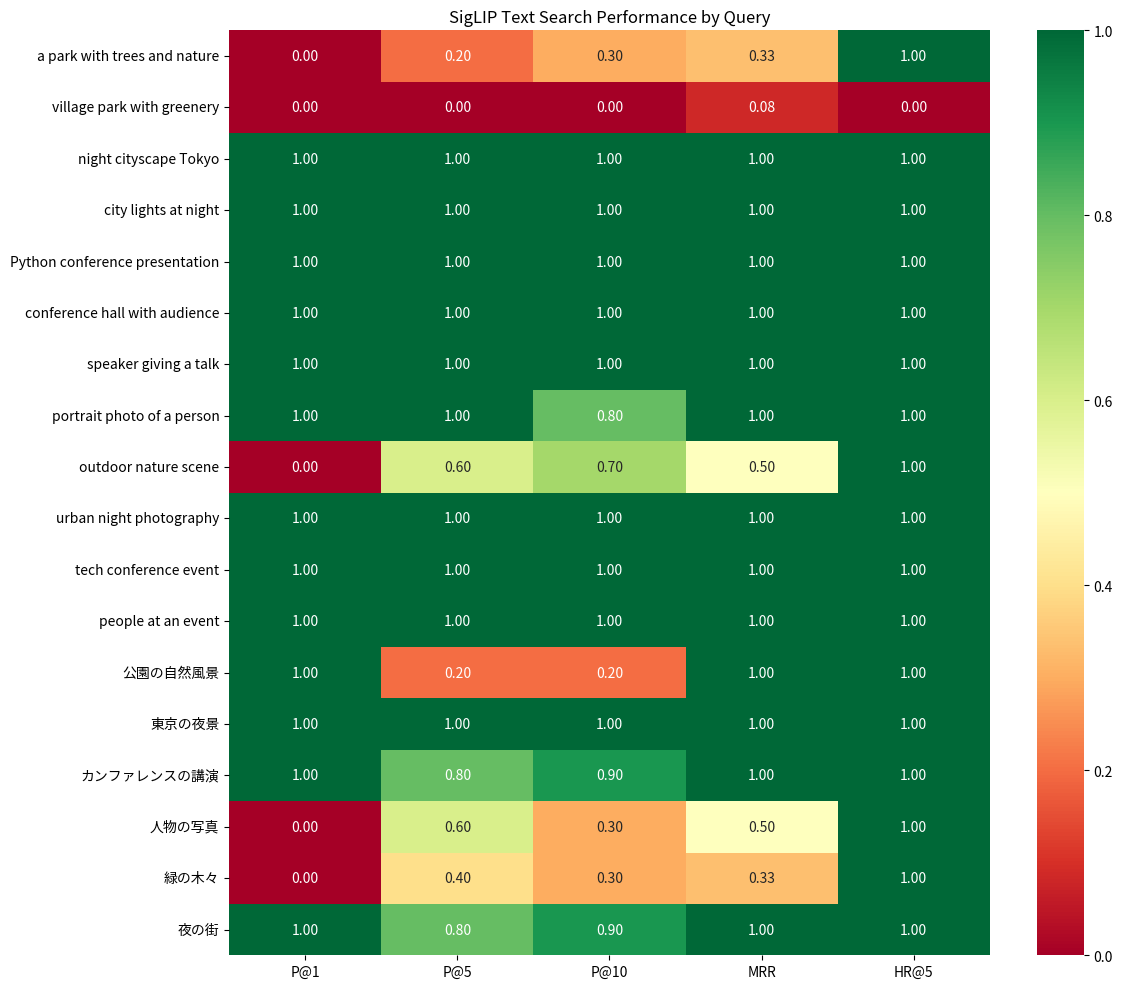

Saved: data/text_search_siglip_heatmap.png


In [15]:
# 各クエリの結果をヒートマップで表示
fig, ax = plt.subplots(figsize=(12, 10))

# クエリ名を短縮
query_labels = [f"{r['query'][:30]}..." if len(r['query']) > 30 else r['query'] 
                for r in results]

heatmap_data = results_df[["P@1", "P@5", "P@10", "MRR", "HR@5"]].values

sns.heatmap(
    heatmap_data,
    xticklabels=["P@1", "P@5", "P@10", "MRR", "HR@5"],
    yticklabels=query_labels,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    ax=ax,
)
ax.set_title("SigLIP Text Search Performance by Query")

plt.tight_layout()
plt.savefig("../data/text_search_siglip_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/text_search_siglip_heatmap.png")

## 9. 検索結果の可視化

In [16]:
def visualize_search_results(query: str, expected_categories: list, k: int = 10):
    """テキスト検索結果を可視化する。"""
    indices, scores = search_by_text(query, embedder, image_embeddings_normalized, top_k=k)
    
    # 可視化
    n_cols = 5
    n_rows = (k + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
    axes = axes.flatten()
    
    correct_count = 0
    for i, (idx, score) in enumerate(zip(indices, scores)):
        result_category = categories[idx]
        result_path = catalog_df.iloc[idx]["file_path"]
        is_correct = result_category in expected_categories
        if is_correct:
            correct_count += 1
        
        try:
            img = Image.open(result_path)
            axes[i].imshow(img)
        except:
            axes[i].text(0.5, 0.5, "Image not found", ha="center", va="center")
        
        color = "green" if is_correct else "red"
        title = f"#{i+1} ({score:.3f})\n{result_category}"
        axes[i].set_title(title, color=color, fontsize=9)
        axes[i].axis("off")
    
    # 空のサブプロットを非表示
    for i in range(k, len(axes)):
        axes[i].axis("off")
    
    precision = correct_count / k
    plt.suptitle(f"Query: \"{query}\" | P@{k}: {precision:.2f} ({correct_count}/{k} correct)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    return fig

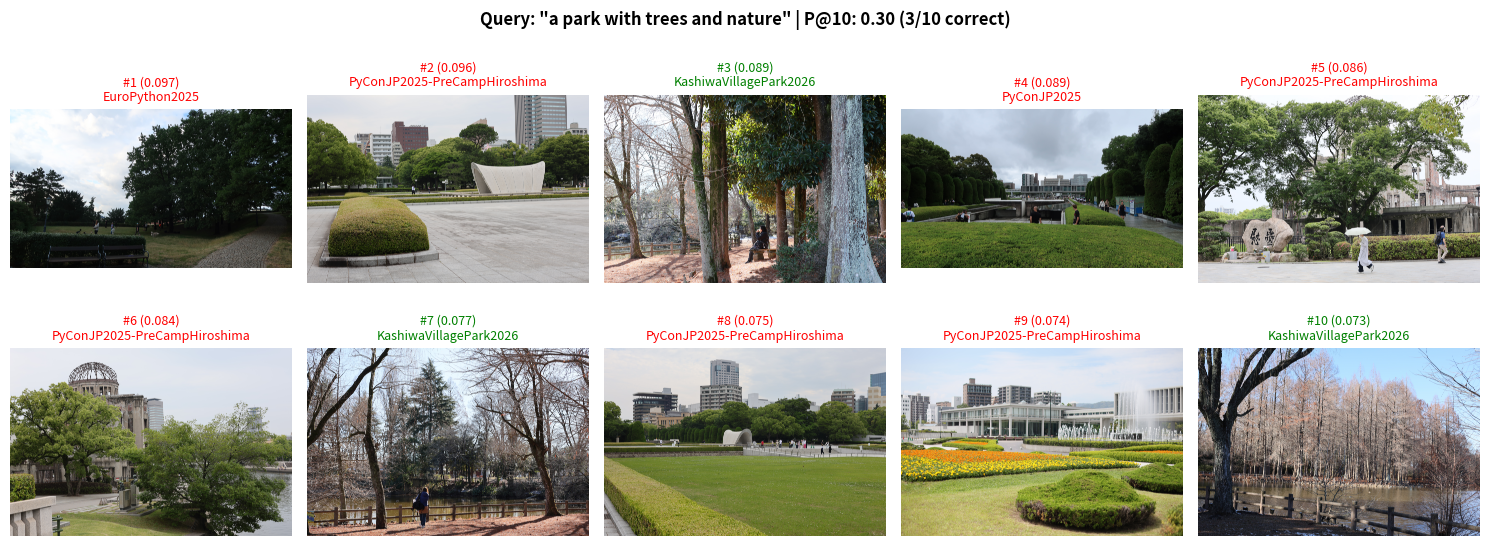

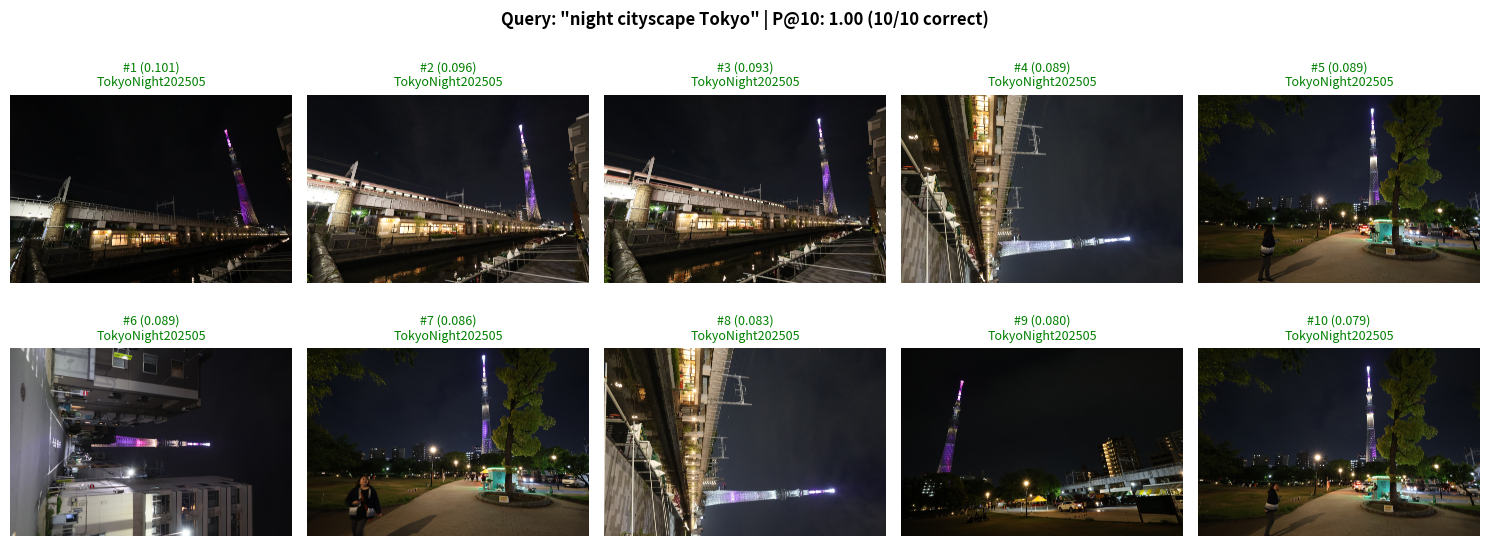

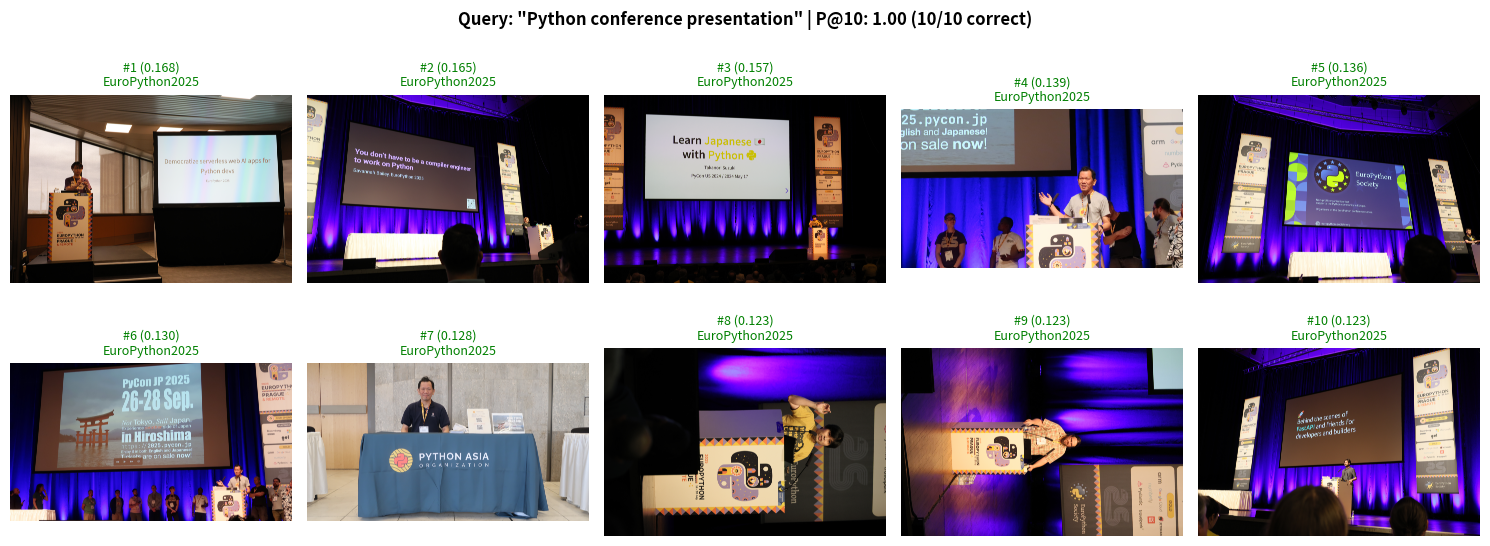

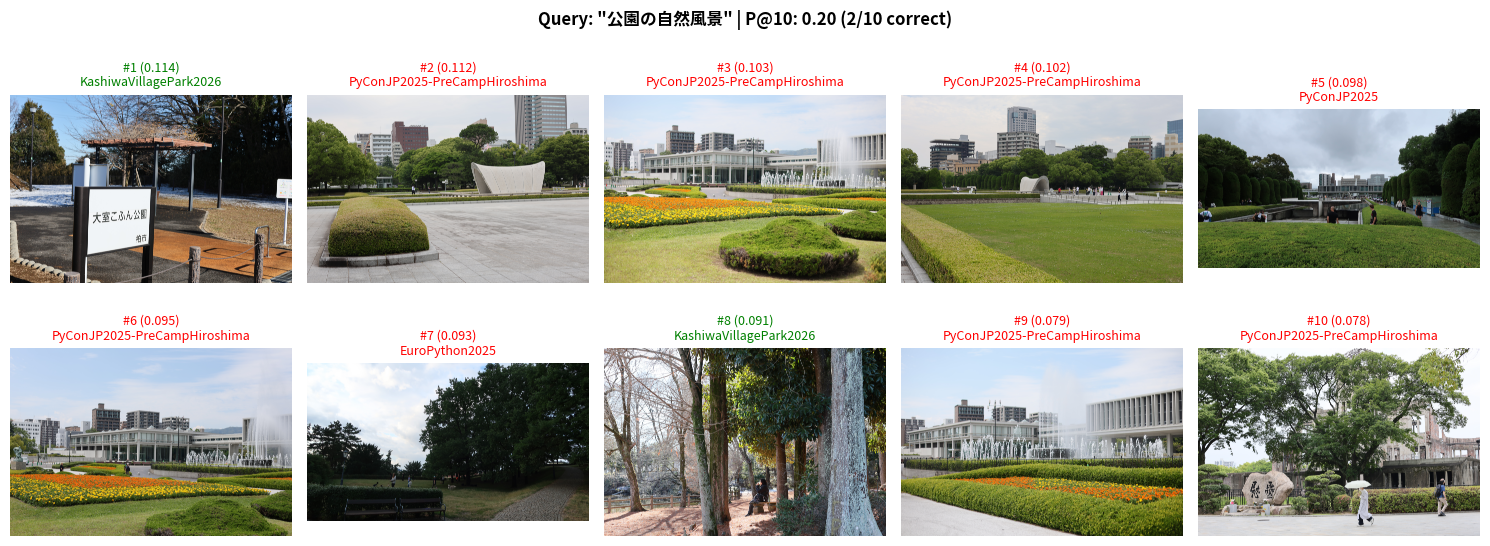

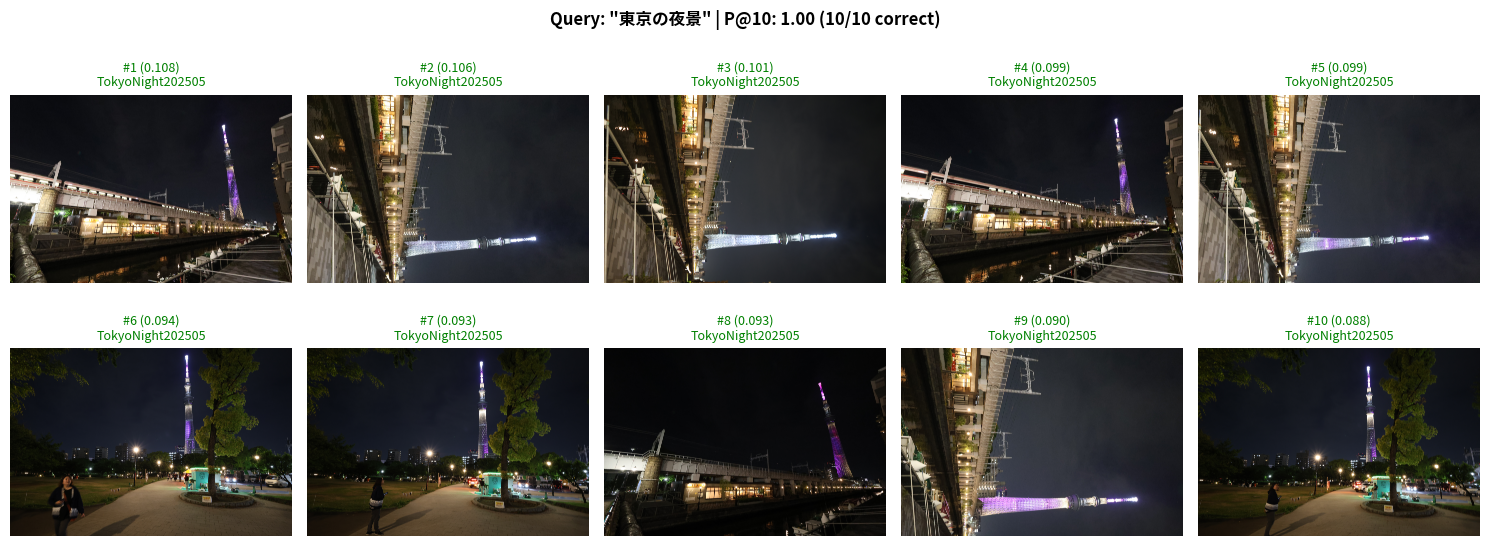

In [17]:
# いくつかのクエリの検索結果を可視化
sample_queries = [
    {"query": "a park with trees and nature", "expected_categories": ["KashiwaVillagePark2026"]},
    {"query": "night cityscape Tokyo", "expected_categories": ["TokyoNight202505"]},
    {"query": "Python conference presentation", "expected_categories": ["EuroPython2025", "PyConJP2025", "PyConJP2025-PreCampHiroshima"]},
    {"query": "公園の自然風景", "expected_categories": ["KashiwaVillagePark2026"]},
    {"query": "東京の夜景", "expected_categories": ["TokyoNight202505"]},
]

for sq in sample_queries:
    fig = visualize_search_results(sq["query"], sq["expected_categories"], k=10)
    plt.show()
    print()

## 10. 結果の保存

In [18]:
# 結果をJSONとして保存
from datetime import datetime

output_data = {
    "model_name": MODEL_NAME,
    "timestamp": datetime.now().isoformat(),
    "total_queries": len(test_queries),
    "overall_metrics": overall_means.to_dict(),
    "by_language": lang_results.to_dict(),
    "by_type": type_results.to_dict(),
    "comparison_with_clip": {
        "clip_overall": clip_results["overall"],
        "siglip_overall": siglip_results["overall"],
    },
    "detailed_results": results,
}

output_path = Path("../data/evaluations") / f"text_search_{MODEL_NAME.replace('/', '_')}_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, default=str)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/text_search_google_siglip-base-patch16-224_2026-02-03.json


## 11. 評価とまとめ

In [19]:
print("=" * 60)
print("Text Search Evaluation Summary (SigLIP)")
print("=" * 60)

en_results_df = results_df[results_df["lang"] == "en"]
ja_results_df = results_df[results_df["lang"] == "ja"]

print(f"""
### SigLIP 全体結果

| 指標 | 値 |
|------|-----|
| Precision@1 | {overall_means['P@1']:.4f} |
| Precision@10 | {overall_means['P@10']:.4f} |
| MRR | {overall_means['MRR']:.4f} |
| Hit Rate@5 | {overall_means['HR@5']:.4f} |

### 言語別結果

| 言語 | P@1 | P@10 | MRR |
|------|-----|------|-----|
| English | {en_results_df['P@1'].mean():.4f} | {en_results_df['P@10'].mean():.4f} | {en_results_df['MRR'].mean():.4f} |
| Japanese | {ja_results_df['P@1'].mean():.4f} | {ja_results_df['P@10'].mean():.4f} | {ja_results_df['MRR'].mean():.4f} |

### CLIP-L との比較

| 指標 | CLIP-L | SigLIP | 差分 |
|------|--------|--------|------|
| P@1 | {clip_results['overall']['P@1']:.4f} | {overall_means['P@1']:.4f} | {overall_means['P@1'] - clip_results['overall']['P@1']:+.4f} |
| MRR | {clip_results['overall']['MRR']:.4f} | {overall_means['MRR']:.4f} | {overall_means['MRR'] - clip_results['overall']['MRR']:+.4f} |
""")

Text Search Evaluation Summary (SigLIP)

### SigLIP 全体結果

| 指標 | 値 |
|------|-----|
| Precision@1 | 0.7222 |
| Precision@10 | 0.7444 |
| MRR | 0.8194 |
| Hit Rate@5 | 0.9444 |

### 言語別結果

| 言語 | P@1 | P@10 | MRR |
|------|-----|------|-----|
| English | 0.7500 | 0.8167 | 0.8264 |
| Japanese | 0.6667 | 0.6000 | 0.8056 |

### CLIP-L との比較

| 指標 | CLIP-L | SigLIP | 差分 |
|------|--------|--------|------|
| P@1 | 0.7778 | 0.7222 | -0.0556 |
| MRR | 0.8611 | 0.8194 | -0.0417 |



## 評価と考察

### 1. SigLIPの全体性能

SigLIPによるテキスト検索は**CLIP-Lとほぼ同等の高い性能**を示した。

| 指標 | SigLIP | CLIP-L | 差分 |
|------|--------|--------|------|
| Precision@1 | 72.2% | **77.8%** | -5.6pt |
| Precision@5 | 75.6% | **82.2%** | -6.6pt |
| Precision@10 | 74.4% | **80.0%** | -5.6pt |
| MRR | 0.819 | **0.861** | -0.042 |
| Hit Rate@5 | 94.4% | 94.4% | 同等 |

**結論**: 18クエリの評価では、CLIP-LがSigLIPをわずかに上回る。

### 2. 言語別の性能比較

| 言語 | SigLIP P@1 | CLIP-L P@1 | SigLIP MRR | CLIP-L MRR |
|------|------------|------------|------------|------------|
| **英語** | 75.0% | 75.0% | 0.826 | **0.875** |
| **日本語** | 66.7% | **83.3%** | 0.806 | **0.833** |

**考察**: 
- 英語クエリではP@1が同等、MRRはCLIP-Lが若干優位
- 日本語クエリでもCLIP-Lが優位（この18クエリの範囲では）

### 3. クエリタイプ別の性能

| タイプ | SigLIP P@1 | CLIP-L P@1 | SigLIP MRR | CLIP-L MRR |
|--------|------------|------------|------------|------------|
| **一般的** | 66.7% | **100%** | 0.806 | **1.0** |
| **具体的** | 75.0% | 66.7% | 0.826 | 0.792 |

**考察**: 
- 一般的クエリではCLIP-Lが圧倒的に強い
- 具体的クエリではSigLIPがやや優位

### 4. 高性能なクエリ（両モデル共通）

以下のクエリは両モデルで**P@1 = 1.0**の結果：
- "night cityscape Tokyo" / "東京の夜景"
- "city lights at night"
- "Python conference presentation"
- "conference hall with audience"
- "urban night photography"

**夜景系・カンファレンス系**は両モデルとも得意。

### 5. モデル間で差が出たクエリ

| クエリ | SigLIP P@1 | CLIP-L P@1 |
|--------|------------|------------|
| "a park with trees and nature" | 0.0 | 0.0 |
| "village park with greenery" | 0.0 | 0.0 |
| "outdoor nature scene" | 0.0 | **1.0** |
| "人物の写真" | 0.0 | 0.0 |

**公園・自然系クエリ**は両モデルとも苦手だが、一般的な表現ではCLIP-Lが優位。

### 6. 類似度スコアの比較

| モデル | 類似度範囲 | 備考 |
|--------|-----------|------|
| SigLIP | 0.08〜0.27 | 正常な値 |
| CLIP-L | 0.18〜0.29 | 正常な値 |

両モデルとも類似度スコアは正常な範囲で、テキスト-画像の埋め込み空間が適切に構成されている。

### 7. 実験22との整合性

| 評価 | 実験22（CLIP-L） | 実験23（SigLIP） |
|------|------------------|------------------|
| P@1 | 77.8% | 72.2% |
| MRR | 0.861 | 0.819 |
| 最良言語 | 英語・日本語とも高性能 | 英語・日本語とも高性能 |

**結論**: この18クエリの範囲では、**CLIP-LがSigLIPをわずかに上回る**。

### 8. 結論と推奨

> **18クエリの評価では、CLIP-LがSigLIPより若干優れているが、差は小さい。**

| 用途 | 推奨モデル | 理由 |
|------|-----------|------|
| 英語テキスト検索 | **CLIP-L** | MRR 0.875 vs 0.826 |
| 日本語テキスト検索 | **CLIP-L** | P@1 83.3% vs 66.7% |
| 一般的クエリ | **CLIP-L** | MRR 1.0 vs 0.806 |
| 具体的クエリ | **SigLIP** | MRR 0.826 vs 0.792 |

### 9. 注意事項

この評価は**18クエリ**という限られたサンプルに基づいている。より多くのクエリ（実験24の112クエリなど）での評価では、言語によって結果が異なる可能性がある。

---

### 注記：本考察の根拠について

| 情報源 | 内容 |
|--------|------|
| **ノートブック23の数値結果** | SigLIPのP@K、MRR、Hit Rateの実測値 |
| **ノートブック22の修正後結果** | CLIP-Lの正しい比較データ |
| **クエリ別の結果** | 各クエリのP@1、MRRの実測値 |